<!-- TEXTO_EXPLICATIVO_ETAPA_1 -->
## Etapa 1 - Construção da Base de Dados

Nesta etapa são carregadas as bases do FBref e do Transfermarkt. O código verifica duplicidades, normaliza os nomes dos jogadores para reduzir diferenças de acentuação/grafia e realiza um `left join`, mantendo todos os atletas do FBref. Ao final, são selecionadas as colunas do dataset final e calculada a cobertura do merge com valores de mercado.


In [58]:
import pandas as pd
from pathlib import Path

caminhos_fbref = [
    Path("../dados/fbref_big5_brasileirao_2526_V2.csv"),
    Path("dados/fbref_big5_brasileirao_2526_V2.csv"),
    Path("content/fbref_big5_brasileirao_2526_V2.csv"),
    Path("../content/fbref_big5_brasileirao_2526_V2.csv"),
    Path("fbref_big5_brasileirao_2526_V2.csv"),
    Path("/content/fbref_big5_brasileirao_2526_V2.csv"),
    Path("../dados/fbref_big5_brasileirao_2526.csv"),
    Path("dados/fbref_big5_brasileirao_2526.csv"),
    Path("fbref_big5_brasileirao_2526.csv"),
    Path("/content/fbref_big5_brasileirao_2526.csv")
]

caminho_fbref = next(
    (caminho for caminho in caminhos_fbref if caminho.exists()),
    None
)

if caminho_fbref is None:
    raise FileNotFoundError(
        "Arquivo FBref nao encontrado. "
        "Verifique se ele esta em dados/, content/, na raiz do projeto ou em /content/."
    )

df_fbref = pd.read_csv(caminho_fbref)

colunas_obrigatorias = [
    "Player", "Nation", "Pos", "Squad", "Age", "Born", "MP", "Min",
    "Gls", "Ast", "CrdY", "CrdR", "Att", "Cmp%", "PrgDist", "SoT",
    "TklW", "Int", "blocks", "Clr", "Saves", "Save%", "CS", "Sh/90", "xG"
]

colunas_ausentes = [
    coluna for coluna in colunas_obrigatorias
    if coluna not in df_fbref.columns
]

if colunas_ausentes:
    raise ValueError(
        "O arquivo FBref carregado nao contem todas as colunas necessarias para o notebook. "
        "Use a versao V2 em dados/fbref_big5_brasileirao_2526_V2.csv. "
        f"Colunas ausentes: {colunas_ausentes}"
    )

print("Arquivo carregado:", caminho_fbref)
print("shape: ")
print(df_fbref.shape)
print("head: ")
print(df_fbref.head())

print("------")
df_fbref.isnull().sum()



Arquivo carregado: content\fbref_big5_brasileirao_2526_V2.csv
shape: 
(2953, 123)
head: 
   Rk             Player  Nation    Pos              Squad               Comp  \
0   1   Brenden Aaronson   usUSA  MF,FW       Leeds United  engPremier League   
1   2        Zach Abbott  engENG     DF  Nottingham Forest  engPremier League   
2   4      Himad Abdelli   dzALG     MF          Marseille          frLigue 1   
3   6           Ali Abdi   tnTUN  MF,DF               Nice          frLigue 1   
4   7  Salis Abdul Samed   ghGHA     MF               Nice          frLigue 1   

      Age    Born  MP  Starts  ...  Cartoes_amarelos  Bloqueios_por_90  \
0  25-204  2000.0  35      28  ...               3.0               0.1   
1  20-001  2006.0   3       2  ...               NaN               NaN   
2  26-178  1999.0   8       1  ...               2.0               0.3   
3  32-145  1993.0  21      12  ...               2.0               0.3   
4  26-049  2000.0  18      12  ...               3.0  

Rk                          0
Player                      0
Nation                      3
Pos                         0
Squad                       0
                         ... 
Jogos_sem_sofrer_gols    2796
Percentual_defesas       2843
Defesas_por_90           2843
Gols_evitados            2843
Gols_sofridos_por_90     2843
Length: 123, dtype: int64

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
from pathlib import Path

caminhos_transfermarkt = [
    Path("../dados/transfermarkt.csv"),
    Path("dados/transfermarkt.csv"),
    Path("transfermarkt.csv"),
    Path("../transfermarkt.csv"),
    Path("/content/transfermarkt.csv")
]

arquivo_transfermarkt = next(
    (caminho for caminho in caminhos_transfermarkt if caminho.exists()),
    Path("../dados/transfermarkt.csv")
)

def converter_valor(valor):

    valor = str(valor).replace("?", "").strip()

    if "mi." in valor.lower():
        numero = float(valor.lower().replace("mi.", "").strip())
        return numero * 1_000_000

    if "mil" in valor.lower():
        numero = float(valor.lower().replace("mil", "").strip())
        return numero * 1_000

    return None

headers = {
    "User-Agent": "Mozilla/5.0"
}

if arquivo_transfermarkt.exists():
    df_transfer = pd.read_csv(arquivo_transfermarkt)
    print("Arquivo Transfermarkt carregado localmente:", arquivo_transfermarkt)
    print(df_transfer.head())
    print(df_transfer.shape)
else:
    jogadores = []

    for pagina in range(1, 9):
        print(f"Coletando p?gina {pagina}")

        url = f"https://www.transfermarkt.com.br/spieler-statistik/wertvollstespieler/marktwertetop/plus/0?galerie=0&page={pagina}"

        try:
            response = requests.get(
                url,
                headers=headers,
                timeout=30
            )
            response.raise_for_status()
        except requests.exceptions.RequestException as erro:
            print(f"Falha ao coletar a pagina {pagina}: {erro}")
            print("A execucao continuara com os dados ja coletados. Se necessario, reexecute mais tarde.")
            break

        soup = BeautifulSoup(response.text, "html.parser")

        for linha in soup.find_all("tr", class_=["odd", "even"]):
            nome = linha.find("td", class_="hauptlink")
            valor = linha.find("td", class_="rechts hauptlink")

            if nome and valor:
                jogador_obj = {
                    "nome": nome.get_text(strip=True),
                    "valor_mercado": converter_valor(valor.get_text(strip=True))
                }

                jogadores.append(jogador_obj)

        time.sleep(2)

    df_transfer = pd.DataFrame(jogadores)

    if df_transfer.empty:
        raise RuntimeError(
            "Nao foi possivel coletar dados do Transfermarkt e nao existe transfermarkt.csv local. "
            "Verifique a conexao ou coloque o CSV em dados/ ou na raiz do projeto."
        )

    print(df_transfer.head())
    print(df_transfer.shape)

    arquivo_transfermarkt.parent.mkdir(parents=True, exist_ok=True)
    df_transfer.to_csv(
        arquivo_transfermarkt,
        index=False,
        encoding="utf-8-sig"
    )

# Foram 200 jogadores do Transfermarkt e 2953 do FBref na execucao original.



Arquivo Transfermarkt carregado localmente: transfermarkt.csv
             nome  valor_mercado
0    Lamine Yamal    200000000.0
1  Erling Haaland    200000000.0
2   Kylian Mbappé    180000000.0
3           Pedri    150000000.0
4   Michael Olise    150000000.0
(200, 2)


In [60]:
import unicodedata

def normalizar_nome(nome):
  nome = str(nome)

  nome = unicodedata.normalize(
      "NFKD", nome
  ).encode(
      "ascii", "ignore"
  ).decode(
      "utf-8"
  )

  nome = nome.lower().strip()

  return nome



In [61]:
#teste de identificação de registros inconsistentes em df_fbref

df_fbref.groupby(
    ["Player", "Born", "Squad"]
).size().value_counts()

chave_jogador = [
    "Player",
    "Born",
    "Squad"
]

duplicados = (
    df_fbref
    .groupby(chave_jogador)
    .size()
    .reset_index(name="qtd")
)

duplicados[duplicados["qtd"] > 1]

,Player,Born,Squad,qtd
445,Carlos Eduardo,1989.0,Mirassol,8
446,Carlos Eduardo,1996.0,Mirassol,8
1883,Matheusinho,1997.0,Vitória,8
1884,Matheusinho,1998.0,Vitória,8


In [62]:
#pegando apenas o primeiro registro quando existe mais de 1 com o mesmo nome, nascimento e time

df_fbref_limpo = (
    df_fbref
    .drop_duplicates(
        subset=["Player", "Born", "Squad"],
        keep="first"
    )
    .copy()
)


print(df_fbref.shape)
print(df_fbref_limpo.shape)

(2953, 123)
(2925, 123)


In [63]:
df_fbref_limpo[
    df_fbref_limpo["Nation"].isna()
][["Player", "Squad", "Age", "Born", "Nation"]]

df_fbref_limpo[
    df_fbref_limpo["Nation"].isna()
][["Player", "Squad", "Age", "Born", "Nation"]]


,Player,Squad,Age,Born,Nation
961,Nathan Mbala,Metz,18-084,2008.0,NaN
1137,Luis Orejuela,Mallorca,NaN,NaN,NaN
1509,Yael Trepy,Cagliari,NaN,NaN,NaN


In [64]:
df_fbref_limpo["nome_norm"] = (
    df_fbref_limpo["Player"]
    .apply(normalizar_nome)
)

df_transfer["nome_norm"] = (
    df_transfer["nome"]
    .apply(normalizar_nome)
)

print(df_fbref_limpo[
    ["Player", "nome_norm", "Born"]
].head())

print(df_transfer.head())

              Player          nome_norm    Born
0   Brenden Aaronson   brenden aaronson  2000.0
1        Zach Abbott        zach abbott  2006.0
2      Himad Abdelli      himad abdelli  1999.0
3           Ali Abdi           ali abdi  1993.0
4  Salis Abdul Samed  salis abdul samed  2000.0
             nome  valor_mercado       nome_norm
0    Lamine Yamal    200000000.0    lamine yamal
1  Erling Haaland    200000000.0  erling haaland
2   Kylian Mbappé    180000000.0   kylian mbappe
3           Pedri    150000000.0           pedri
4   Michael Olise    150000000.0   michael olise


In [65]:
df_pre_final = df_fbref_limpo.merge(
    df_transfer[
        ["nome_norm", "valor_mercado"]
    ],
    on="nome_norm",
    how="left"
)

print(df_transfer)

df_pre_final["idade"] = (
    df_pre_final["Age"]
    .str.split("-")
    .str[0]
)

df_pre_final = df_pre_final.rename(
    columns={
        "nome_norm": "nome",
        "Pos": "posicao",
        "Nation": "nacionalidade",
        "Squad": "clube",
        "MP": "jogos",
        "Min": "minutos",
        "Gls": "gols",
        "Ast": "assistencias",
        "CrdY": "amarelos",
        "CrdR": "vermelhos",
        "Att": "passes_tent",
        "Cmp%": "pct_passes",
        "PrgDist": "passes_prog",
        "SoT": "chutes_gol",
        "TklW": "desarmes",
        "Int": "interceptacoes",
        "blocks": "bloqueios",
        "Clr": "cortes",
        "Saves": "defesas_gk",
        "Save%": "pct_defesas",
        "CS": "clean_sheets",
        "Sh/90": "chutes",
        "xG": "xG"
    }
)

colunas_zerar = [
    "gols",
    "assistencias",
    "amarelos",
    "vermelhos",
    "passes_tent",
    "pct_passes",
    "passes_prog",
    "chutes",
    "chutes_gol",
    "xG",
    "desarmes",
    "interceptacoes",
    "bloqueios",
    "cortes",
    "defesas_gk",
    "pct_defesas",
    "clean_sheets"
]

colunas_finais = [
    "nome",
    "valor_mercado",
    "posicao",
    "idade",
    "nacionalidade",
    "clube",
    "jogos",
    "minutos",
    "gols",
    "assistencias",
    "amarelos",
    "vermelhos",
    "passes_tent",
    "pct_passes",
    "passes_prog",
    "chutes",
    "chutes_gol",
    "xG",
    "desarmes",
    "interceptacoes",
    "bloqueios",
    "cortes",
    "defesas_gk",
    "pct_defesas",
    "clean_sheets"
]

df_pre_final[colunas_zerar] = (
    df_pre_final[colunas_zerar]
    .fillna(0)
)

dataset_final = df_pre_final[colunas_finais]


print(dataset_final.head())



print("-------------------------------")

print(
    "Jogadores com valor de mercado:",
    dataset_final["valor_mercado"]
    .notna()
    .sum()
)

print(
    "Jogadores sem valor de mercado:",
    dataset_final["valor_mercado"]
    .isna()
    .sum()
)

caminho_dataset_final = Path("../dados/dataset_final.csv")
if not caminho_dataset_final.parent.exists():
    caminho_dataset_final = Path("dataset_final.csv")

dataset_final.to_csv(
    caminho_dataset_final,
    index=False,
    encoding="utf-8-sig"
)

print("Dataset final salvo em:", caminho_dataset_final)

df_transfer[
    df_transfer["nome_norm"] == "vitinha"
]

dataset_final[
    dataset_final["nome"] == "vitinha"
][
    ["nome", "clube", "idade", "valor_mercado"]
]


                     nome  valor_mercado            nome_norm
0            Lamine Yamal    200000000.0         lamine yamal
1          Erling Haaland    200000000.0       erling haaland
2           Kylian Mbappé    180000000.0        kylian mbappe
3                   Pedri    150000000.0                pedri
4           Michael Olise    150000000.0        michael olise
..                    ...            ...                  ...
195     Lisandro Martínez     40000000.0    lisandro martinez
196         Nico González     40000000.0        nico gonzalez
197           Eric García     40000000.0          eric garcia
198       Christos Tzolis     40000000.0      christos tzolis
199  Jørgen Strand Larsen     40000000.0  jrgen strand larsen

[200 rows x 3 columns]
                nome  valor_mercado posicao idade nacionalidade  \
0   brenden aaronson            NaN   MF,FW    25         usUSA   
1        zach abbott            NaN      DF    20        engENG   
2      himad abdelli           

,nome,clube,idade,valor_mercado
1565,vitinha,Paris Saint-Germain,26,140000000.0
1566,vitinha,Genoa,26,140000000.0


<!-- TEXTO_EXPLICATIVO_ETAPA_2 -->
## Etapa 2 - Pré-processamento e Análise Exploratória

Nesta etapa as posições são simplificadas para GK, DF, MF e FW, os campos numéricos são convertidos para o tipo correto e valores ausentes posicionais são preenchidos com zero. Em seguida, as variáveis numéricas são normalizadas e são geradas visualizações para interpretar valor de mercado, perfil por posição, nacionalidades, idade e relação entre xG e gols.


In [66]:
#Posição: simplifique para quatro grupos.

def simplificar_posicao(pos):
    if "GK" in pos:
        return "GK"
    elif "FW" in pos:
        return "FW"
    elif "MF" in pos:
        return "MF"
    elif "DF" in pos:
        return "DF"

In [67]:
dataset_final = dataset_final.copy()

dataset_final["posicao"] = (
    dataset_final["posicao"]
    .apply(simplificar_posicao)
)

colunas_numericas = [
    "idade",
    "jogos",
    "minutos",
    "gols",
    "assistencias",
    "amarelos",
    "vermelhos",
    "passes_tent",
    "pct_passes",
    "passes_prog",
    "chutes",
    "chutes_gol",
    "xG",
    "desarmes",
    "interceptacoes",
    "bloqueios",
    "cortes",
    "defesas_gk",
    "pct_defesas",
    "clean_sheets",
    "valor_mercado"
]

for col in colunas_numericas:
    dataset_final[col] = pd.to_numeric(
        dataset_final[col],
        errors="coerce"
    )

print(dataset_final.info())

<class 'pandas.DataFrame'>
RangeIndex: 2925 entries, 0 to 2924
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   nome            2925 non-null   str    
 1   valor_mercado   196 non-null    float64
 2   posicao         2925 non-null   str    
 3   idade           2923 non-null   float64
 4   nacionalidade   2922 non-null   str    
 5   clube           2925 non-null   str    
 6   jogos           2925 non-null   int64  
 7   minutos         2925 non-null   int64  
 8   gols            2925 non-null   int64  
 9   assistencias    2925 non-null   int64  
 10  amarelos        2925 non-null   int64  
 11  vermelhos       2925 non-null   int64  
 12  passes_tent     2925 non-null   float64
 13  pct_passes      2925 non-null   float64
 14  passes_prog     2925 non-null   float64
 15  chutes          2925 non-null   float64
 16  chutes_gol      2925 non-null   int64  
 17  xG              2925 non-null   float64
 18 

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_escalado = dataset_final.copy()
colunas_numericas_sem_target = [
    col
    for col in colunas_numericas
    if col != "valor_mercado"
]

df_escalado[colunas_numericas_sem_target] = scaler.fit_transform(
    dataset_final[colunas_numericas_sem_target]
)

print(df_escalado)

                   nome  valor_mercado posicao     idade nacionalidade  \
0      brenden aaronson            NaN      FW -0.315202         usUSA   
1           zach abbott            NaN      DF -1.423375        engENG   
2         himad abdelli            NaN      MF -0.093567         dzALG   
3              ali abdi            NaN      MF  1.236240         tnTUN   
4     salis abdul samed            NaN      MF -0.093567         ghGHA   
...                 ...            ...     ...       ...           ...   
2920      alix vinicius            NaN      DF -0.093567         brBRA   
2921             wagner            NaN      DF -0.093567         brBRA   
2922       jose welison            NaN      MF  1.014606         brBRA   
2923            willian            NaN      MF  1.236240         brBRA   
2924               yuri            NaN      MF  1.236240         brBRA   

                  clube     jogos   minutos      gols  assistencias  ...  \
0          Leeds United  1.621858  

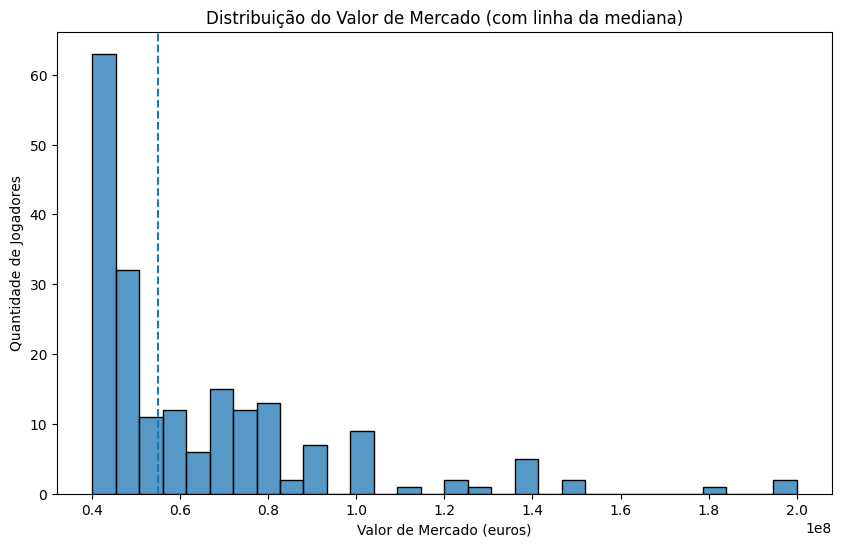

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.histplot(
    dataset_final["valor_mercado"].dropna(),
    bins=30
)

plt.axvline(
    dataset_final["valor_mercado"].median(),
    linestyle="--"
)

plt.title("Distribuição do Valor de Mercado (com linha da mediana)")
plt.xlabel("Valor de Mercado (euros)")
plt.ylabel("Quantidade de Jogadores")

plt.show()

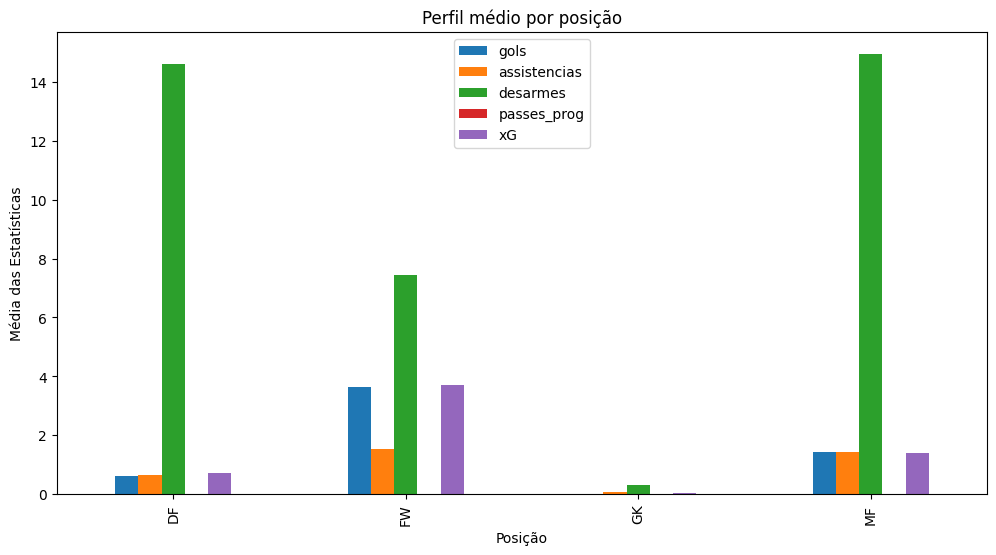

In [70]:
perfil = (
    dataset_final
    .groupby("posicao")
    [
        [
            "gols",
            "assistencias",
            "desarmes",
            "passes_prog",
            "xG"
        ]
    ]
    .mean()
)

perfil.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Perfil médio por posição")
plt.xlabel("Posição")
plt.ylabel("Média das Estatísticas")

plt.show()

               qtd   valor_medio
nacionalidade                   
ptPOR            9  8.500000e+07
frFRA           23  7.434783e+07
esESP           19  6.763158e+07
engENG          27  6.722222e+07
brBRA           23  6.434783e+07
arARG            9  6.166667e+07
deGER           17  5.617647e+07
itITA            7  5.500000e+07
nlNED           12  5.041667e+07


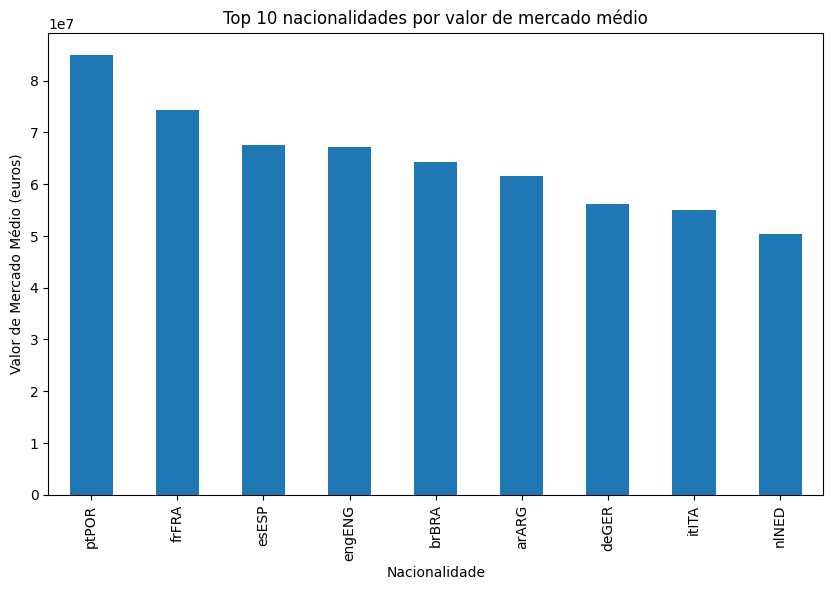

In [71]:
nac = (
    dataset_final
    .dropna(subset=["valor_mercado"])  # mantém apenas quem tem valor
    .groupby("nacionalidade")
    .agg(
        qtd=("valor_mercado", "count"),
        valor_medio=("valor_mercado", "mean")
    )
)

# exige pelo menos 5 jogadores COM valor de mercado
nac = nac[nac["qtd"] >= 5]

top10 = (
    nac
    .sort_values(
        "valor_medio",
        ascending=False
    )
    .head(10)
)

print(top10)

top10["valor_medio"].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Top 10 nacionalidades por valor de mercado médio")
plt.xlabel("Nacionalidade")
plt.ylabel("Valor de Mercado Médio (euros)")
plt.show()

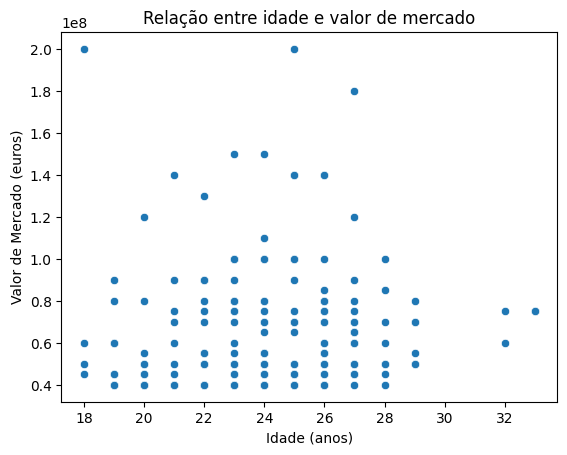

In [72]:
sns.scatterplot(
    data=dataset_final,
    x="idade",
    y="valor_mercado"
)

plt.title("Relação entre idade e valor de mercado")
plt.xlabel("Idade (anos)")
plt.ylabel("Valor de Mercado (euros)")

plt.show()

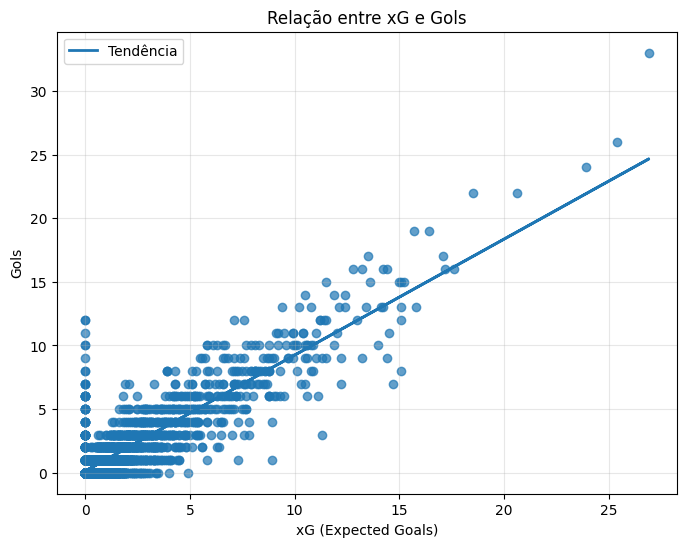

In [73]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(dataset_final['xG'], dataset_final['gols'], alpha=0.7)

# linha de tendencia
z = np.polyfit(dataset_final['xG'], dataset_final['gols'], 1)
p = np.poly1d(z)

plt.plot(
    dataset_final['xG'],
    p(dataset_final['xG']),
    linewidth=2,
    label='Tendência'
)

plt.title('Relação entre xG e Gols')
plt.xlabel('xG (Expected Goals)')
plt.ylabel('Gols')
plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

<!-- TEXTO_EXPLICATIVO_ETAPA_3 -->
## Etapa 3 - Clusterização

Nesta etapa os jogadores são agrupados por similaridade estatística usando K-Means. As variáveis relevantes são normalizadas, o número de clusters é avaliado pelo Método do Cotovelo e pelo Silhouette Score, e a visualização em PCA 2D ajuda a interpretar os perfis encontrados. Depois, os clusters são caracterizados pelas médias das principais estatísticas.


In [74]:
#ETAPA 3

map_pos = {
    "GK": 0,
    "DF": 1,
    "MF": 2,
    "FW": 3
}

dataset_final["posicao_num"] = (
    dataset_final["posicao"]
        .map(map_pos)
)

In [75]:
features_cluster = [
    "minutos",
    "gols",
    "assistencias",
    "xG",
    "desarmes",
    "interceptacoes",
    "chutes",
    "chutes_gol",
    "defesas_gk",
    "clean_sheets",
    "idade",
    "posicao_num"
]

X = dataset_final[
    features_cluster
].copy()

#preenchendo idades NaN com a mediana das idades
X["idade"] = X["idade"].fillna(
    X["idade"].median()
)


In [76]:
#nomarlização
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 1.26497116  0.84370843  2.19933475  1.09253755  1.22795939  0.61295245
   0.41775409  1.50566204 -0.21888696 -0.20073984 -0.3152447   1.30996029]
 [-1.24171462 -0.59863357 -0.66030881 -0.6328052  -0.6931528  -0.74735553
  -1.20926584 -0.75261388 -0.21888696 -0.20073984 -1.42379334 -0.96333182]
 [-1.27221243 -0.59863357 -0.66030881  0.15485128 -0.95512265 -0.74735553
   1.31842584 -0.61147163 -0.21888696 -0.20073984 -0.09353498  0.17331424]
 [-0.14731227  0.48312293 -0.66030881  0.26737363 -0.16921311 -0.02185794
  -0.33764802 -0.32918714 -0.21888696 -0.20073984  1.23672339  0.17331424]
 [-0.36548894 -0.59863357 -0.66030881 -0.6328052  -0.43118296  0.06882926
  -1.11241942 -0.75261388 -0.21888696 -0.20073984 -0.09353498  0.17331424]]


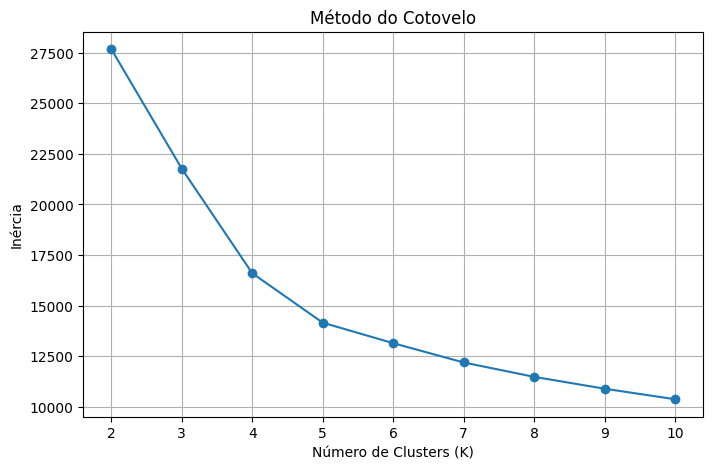

In [77]:
#método do cotovelo

from sklearn.cluster import KMeans

inercia = [];

for k in range(2, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_scaled)

    inercia.append(modelo.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inercia,
    marker="o"
)

plt.title("Método do Cotovelo")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inércia")

plt.grid(True)

plt.show()

K = 2: 0.270
K = 3: 0.310
K = 4: 0.302
K = 5: 0.251
K = 6: 0.237
K = 7: 0.211
K = 8: 0.194
K = 9: 0.198
K = 10: 0.196


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

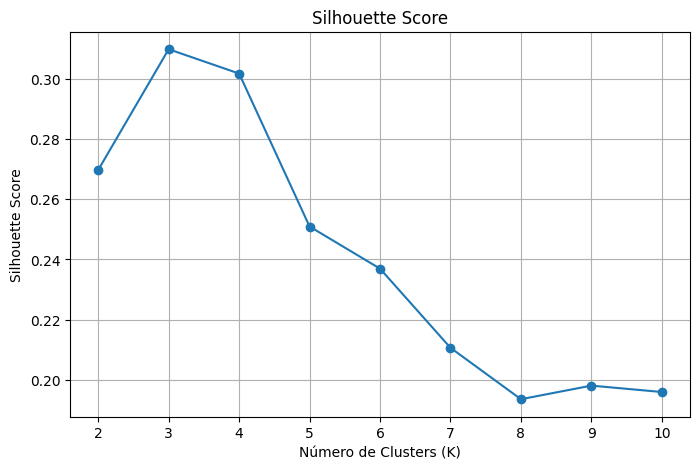

In [78]:
#Silhouette Score - confirmar a escolha

from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = modelo.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

    print(f"K = {k}: {score:.3f}")

    plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker="o"
)

plt.title("Silhouette Score")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Silhouette Score")

plt.grid(True)

plt.show()


In [79]:
#criação dos clusters

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

dataset_cluster = dataset_final.copy()

dataset_cluster["cluster"] = kmeans.fit_predict(X_scaled)


In [80]:

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

dataset_cluster = dataset_final.copy()

dataset_cluster["cluster"] = kmeans.fit_predict(X_scaled)

dataset_cluster["cluster"].value_counts().sort_index()

pd.crosstab(
    dataset_cluster["cluster"],
    dataset_cluster["posicao"]
)

posicao,DF,FW,GK,MF
cluster,,,,
0,1,248,0,83
1,414,470,91,734
2,347,16,0,403
3,0,0,118,0


In [81]:
resumo_clusters = (
    dataset_cluster
    .groupby("cluster")[
        [
            "idade",
            "gols",
            "assistencias",
            "xG",
            "desarmes",
            "interceptacoes",
            "chutes",
            "chutes_gol",
            "defesas_gk",
            "pct_defesas",
            "clean_sheets"
        ]
    ]
    .mean()
    .round(2)
)

resumo_clusters

,idade,gols,assistencias,xG,desarmes,interceptacoes,chutes,chutes_gol,defesas_gk,pct_defesas,clean_sheets
cluster,,,,,,,,,,,
0,26.30,7.56,3.34,7.37,13.23,8.69,2.58,20.92,0.00,0.00,0.00
1,26.03,0.76,0.56,0.82,6.16,4.76,1.29,2.78,0.78,3.58,0.06
2,26.81,1.36,1.69,1.42,26.04,24.67,0.76,5.09,0.00,0.00,0.00
3,29.88,0.00,0.13,0.01,0.43,0.35,0.00,0.01,77.02,70.19,7.34


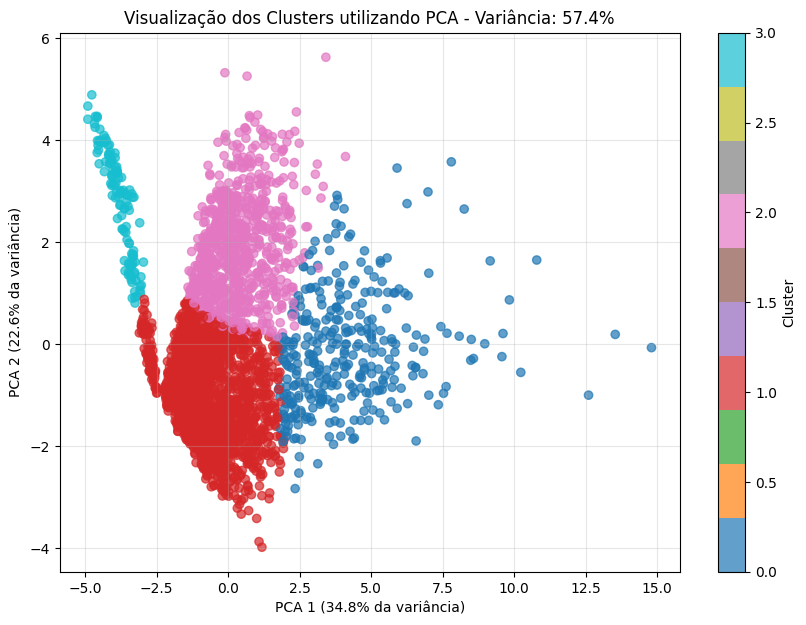

In [82]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

dataset_cluster["PCA1"] = X_pca[:,0]
dataset_cluster["PCA2"] = X_pca[:,1]

variancia = pca.explained_variance_ratio_

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    dataset_cluster["PCA1"],
    dataset_cluster["PCA2"],
    c=dataset_cluster["cluster"],
    cmap="tab10",
    alpha=0.7
)

plt.colorbar(scatter,label="Cluster")

plt.xlabel(
    f"PCA 1 ({variancia[0]*100:.1f}% da variância)"
)

plt.ylabel(
    f"PCA 2 ({variancia[1]*100:.1f}% da variância)"
)

plt.title(f"Visualização dos Clusters utilizando PCA - Variância: {variancia.sum()*100:.1f}%")

plt.grid(alpha=0.3)

plt.show()

In [83]:
# Cobertura percentual do merge FBref + Transfermarkt
jogadores_com_valor = dataset_final["valor_mercado"].notna().sum()
total_jogadores = len(dataset_final)
cobertura_merge = jogadores_com_valor / total_jogadores * 100

print(f"Jogadores com valor de mercado: {jogadores_com_valor}")
print(f"Total de jogadores no dataset final: {total_jogadores}")
print(f"Cobertura percentual do merge: {cobertura_merge:.2f}%")


Jogadores com valor de mercado: 196
Total de jogadores no dataset final: 2925
Cobertura percentual do merge: 6.70%


<!-- TEXTO_EXPLICATIVO_ETAPA_4 -->
## Etapa 4 - Classificação

Nesta etapa é criado um alvo binário a partir da mediana de minutos jogados, separando jogadores de rotação e titulares regulares. Para evitar vazamento de dados, variáveis diretamente ligadas ao alvo, como minutos, 90s, Starts e valor de mercado, são removidas das features. Em seguida, dois modelos são avaliados com validação cruzada estratificada e métricas de classificação.


In [84]:
# ETAPA 4 - Classificacao: criacao correta do target

mediana_minutos = dataset_final["minutos"].median()

df_classificacao = dataset_final.copy()
df_classificacao["target"] = (
    df_classificacao["minutos"] > mediana_minutos
).astype(int)

print("Mediana de minutos:", mediana_minutos)
print("Distribuicao do target:")
print(df_classificacao["target"].value_counts().sort_index())
print()
print("Classe 0 = Rotacao/Reserva")
print("Classe 1 = Titular Regular / Nivel Copa")


Mediana de minutos: 1041.0
Distribuicao do target:
target
0    1463
1    1462
Name: count, dtype: int64

Classe 0 = Rotacao/Reserva
Classe 1 = Titular Regular / Nivel Copa


In [85]:
# ETAPA 4 - Preparacao das features sem data leakage

map_pos = {
    "GK": 0,
    "DF": 1,
    "MF": 2,
    "FW": 3
}

df_classificacao["posicao_num"] = df_classificacao["posicao"].map(map_pos)

features_modelo = [
    "idade",
    "jogos",
    "gols",
    "assistencias",
    "amarelos",
    "vermelhos",
    "passes_tent",
    "pct_passes",
    "passes_prog",
    "chutes",
    "chutes_gol",
    "xG",
    "desarmes",
    "interceptacoes",
    "bloqueios",
    "cortes",
    "defesas_gk",
    "pct_defesas",
    "clean_sheets",
    "posicao_num"
]

variaveis_removidas_por_leakage = [
    "minutos",
    "90s",
    "Starts",
    "valor_mercado"
]

X_classificacao = df_classificacao[features_modelo].copy()

for coluna in X_classificacao.columns:
    X_classificacao[coluna] = pd.to_numeric(
        X_classificacao[coluna],
        errors="coerce"
    )
    X_classificacao[coluna] = X_classificacao[coluna].fillna(
        X_classificacao[coluna].median()
    )

y_classificacao = df_classificacao["target"]

print("Features usadas no modelo:")
print(features_modelo)
print()
print("Variaveis removidas para evitar data leakage:")
print(variaveis_removidas_por_leakage)
print()
print("Shape X:", X_classificacao.shape)


Features usadas no modelo:
['idade', 'jogos', 'gols', 'assistencias', 'amarelos', 'vermelhos', 'passes_tent', 'pct_passes', 'passes_prog', 'chutes', 'chutes_gol', 'xG', 'desarmes', 'interceptacoes', 'bloqueios', 'cortes', 'defesas_gk', 'pct_defesas', 'clean_sheets', 'posicao_num']

Variaveis removidas para evitar data leakage:
['minutos', '90s', 'Starts', 'valor_mercado']

Shape X: (2925, 20)


In [86]:
# ETAPA 4 - Modelos, validacao cruzada estratificada e metricas obrigatorias

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

modelos = {
    "Regressao Logistica": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "modelo",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=42
                )
            )
        ]
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )
}

metricas = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

resultados_modelos = []
predicoes_cv = {}

for nome_modelo, modelo in modelos.items():
    resultado_cv = cross_validate(
        modelo,
        X_classificacao,
        y_classificacao,
        cv=cv,
        scoring=metricas,
        n_jobs=-1
    )

    y_pred = cross_val_predict(
        modelo,
        X_classificacao,
        y_classificacao,
        cv=cv,
        n_jobs=-1
    )

    predicoes_cv[nome_modelo] = y_pred

    resultados_modelos.append(
        {
            "modelo": nome_modelo,
            "accuracy": resultado_cv["test_accuracy"].mean(),
            "precision": resultado_cv["test_precision"].mean(),
            "recall": resultado_cv["test_recall"].mean(),
            "f1": resultado_cv["test_f1"].mean(),
            "accuracy_std": resultado_cv["test_accuracy"].std(),
            "precision_std": resultado_cv["test_precision"].std(),
            "recall_std": resultado_cv["test_recall"].std(),
            "f1_std": resultado_cv["test_f1"].std()
        }
    )

comparacao_modelos = pd.DataFrame(resultados_modelos).round(3)
comparacao_modelos


,modelo,accuracy,precision,recall,f1,accuracy_std,precision_std,recall_std,f1_std
0,Regressao Logistica,0.939,0.944,0.934,0.939,0.009,0.022,0.011,0.008
1,Random Forest,0.933,0.933,0.933,0.933,0.006,0.016,0.015,0.006


In [87]:
# ETAPA 4 - Matrizes de confusao e relatorios por modelo

for nome_modelo, y_pred in predicoes_cv.items():
    print("=" * 70)
    print(nome_modelo)
    print("Matriz de confusao:")
    print(confusion_matrix(y_classificacao, y_pred))
    print()
    print("Relatorio de classificacao:")
    print(
        classification_report(
            y_classificacao,
            y_pred,
            digits=3
        )
    )


Regressao Logistica
Matriz de confusao:
[[1381   82]
 [  96 1366]]

Relatorio de classificacao:
              precision    recall  f1-score   support

           0      0.935     0.944     0.939      1463
           1      0.943     0.934     0.939      1462

    accuracy                          0.939      2925
   macro avg      0.939     0.939     0.939      2925
weighted avg      0.939     0.939     0.939      2925

Random Forest
Matriz de confusao:
[[1364   99]
 [  98 1364]]

Relatorio de classificacao:
              precision    recall  f1-score   support

           0      0.933     0.932     0.933      1463
           1      0.932     0.933     0.933      1462

    accuracy                          0.933      2925
   macro avg      0.933     0.933     0.933      2925
weighted avg      0.933     0.933     0.933      2925



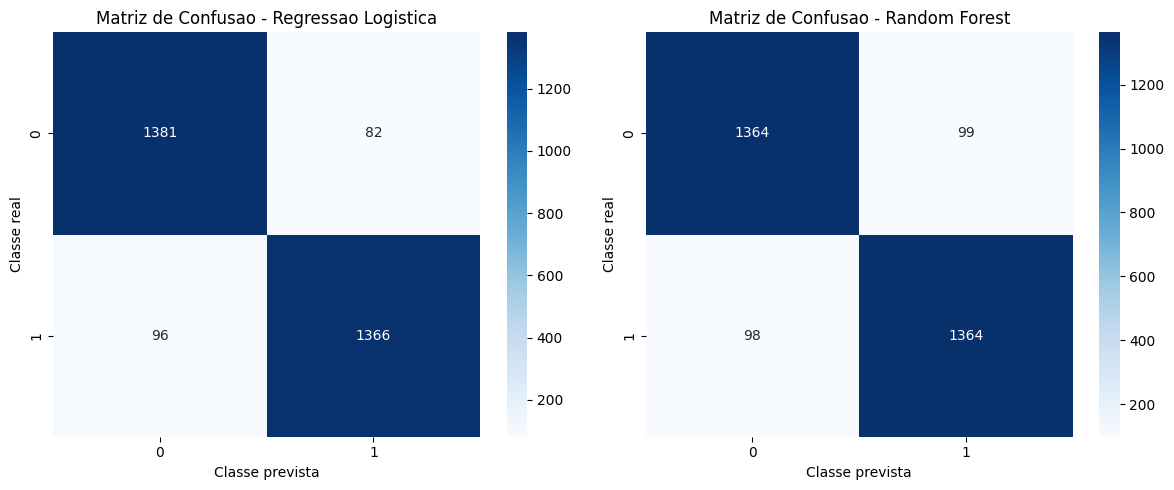

In [88]:
# ETAPA 4 - Visualizacao das matrizes de confusao

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (nome_modelo, y_pred) in zip(axes, predicoes_cv.items()):
    matriz = confusion_matrix(y_classificacao, y_pred)
    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )
    ax.set_title(f"Matriz de Confusao - {nome_modelo}")
    ax.set_xlabel("Classe prevista")
    ax.set_ylabel("Classe real")

plt.tight_layout()
plt.show()


           feature  importancia
1            jogos     0.307056
12        desarmes     0.155863
13  interceptacoes     0.138632
10      chutes_gol     0.068719
4         amarelos     0.062974
11              xG     0.050704
9           chutes     0.046500
2             gols     0.035908
3     assistencias     0.032346
16      defesas_gk     0.028229


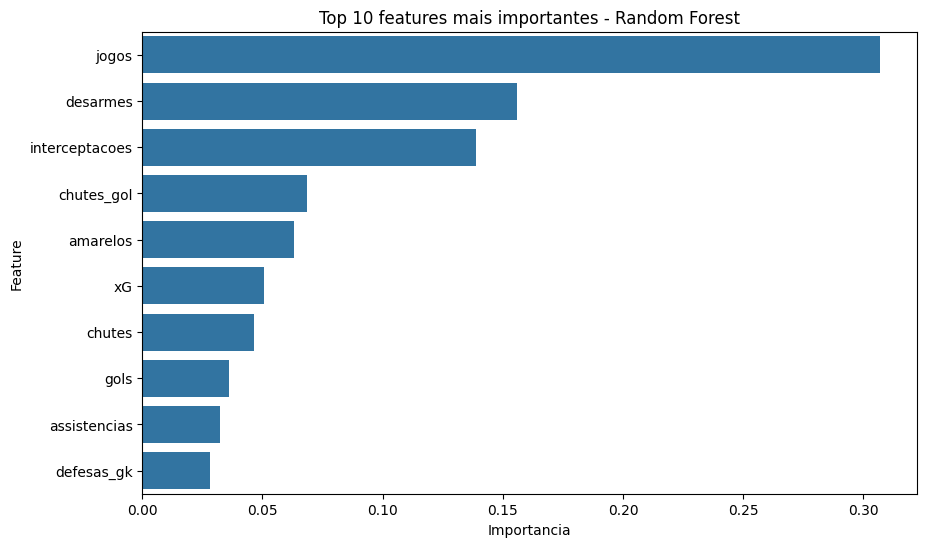

In [89]:
# ETAPA 4 - Importancia das features pelo Random Forest

modelo_rf_final = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

modelo_rf_final.fit(
    X_classificacao,
    y_classificacao
)

importancia_features = (
    pd.DataFrame(
        {
            "feature": features_modelo,
            "importancia": modelo_rf_final.feature_importances_
        }
    )
    .sort_values("importancia", ascending=False)
)

print(importancia_features.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importancia_features.head(10),
    x="importancia",
    y="feature"
)
plt.title("Top 10 features mais importantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Feature")
plt.show()


<!-- TEXTO_EXPLICATIVO_ETAPA_4 -->
### Interpretação da Etapa 4

A variável-alvo foi construída a partir da mediana de minutos jogados, separando atletas de maior uso competitivo dos atletas de rotação. A Regressão Logística e o Random Forest apresentaram desempenho próximo, com métricas altas e classes balanceadas. As features mais importantes indicam que regularidade de participação, intensidade defensiva e produção ofensiva ajudam a identificar jogadores em nível competitivo.

No contexto de convocação para a Copa, o falso negativo tende a ser mais grave do que o falso positivo, pois deixar de identificar um jogador realmente competitivo pode reduzir as opções da comissão técnica. Já um falso positivo ainda pode ser filtrado por análise tática, observação em vídeo e avaliação médica.


<!-- TEXTO_EXPLICATIVO_ETAPA_5 -->
## Etapa 5 - Recomendação Estratégica

Nesta etapa os resultados de clusterização e classificação são integrados para apoiar uma recomendação de elenco. A análise prioriza perfis complementares, oportunidades de custo-benefício e jogadores classificados como nível competitivo pelo modelo, sempre considerando as limitações dos dados disponíveis.


In [90]:
# ETAPA 5 - Jogadores reais classificados como Nivel Copa e possiveis oportunidades

nome_modelo_recomendacao = "Random Forest"
df_classificacao["pred_random_forest_cv"] = predicoes_cv[nome_modelo_recomendacao]

jogadores_nivel_copa = (
    df_classificacao[
        (df_classificacao["target"] == 1) &
        (df_classificacao["pred_random_forest_cv"] == 1)
    ]
    .copy()
)

jogadores_recomendados = (
    jogadores_nivel_copa
    .assign(
        valor_mercado_ordenacao=jogadores_nivel_copa["valor_mercado"].fillna(-1)
    )
    .sort_values(
        [
            "valor_mercado_ordenacao",
            "gols",
            "assistencias",
            "desarmes",
            "interceptacoes"
        ],
        ascending=[True, False, False, False, False]
    )
    [
        [
            "nome",
            "clube",
            "posicao",
            "idade",
            "minutos",
            "gols",
            "assistencias",
            "desarmes",
            "interceptacoes",
            "xG",
            "valor_mercado"
        ]
    ]
    .head(15)
)

jogadores_recomendados


,nome,clube,posicao,idade,minutos,gols,assistencias,desarmes,interceptacoes,xG,valor_mercado
1059,vedat muriqi,Mallorca,FW,32.0,2948,22,1,3,3,18.5,NaN
2434,deniz undav,Stuttgart,FW,29.0,2151,19,6,13,4,16.4,NaN
841,esteban lepaul,Rennes,FW,26.0,2421,19,5,5,3,15.7,NaN
226,ante budimir,Osasuna,FW,34.0,2758,17,0,16,6,17.1,NaN
2361,patrik schick,Leverkusen,FW,30.0,1898,16,3,4,3,17.2,NaN
1170,joaquin panichelli,Strasbourg,FW,23.0,2193,16,1,10,13,14.2,NaN
2118,serhou guirassy,Dortmund,FW,30.0,2255,16,1,1,0,17.6,NaN
1155,mikel oyarzabal,Real Sociedad,FW,29.0,2572,15,3,16,4,15.2,NaN
2192,andrej kramaric,Hoffenheim,FW,34.0,2153,14,6,5,7,11.9,NaN
2147,borja iglesias,Celta Vigo,FW,33.0,1769,14,2,5,0,10.5,NaN


<!-- TEXTO_EXPLICATIVO_ETAPA_5 -->
### Recomendação Estratégica - Etapa 5

Para uma convocação equilibrada, a federação deve combinar os quatro perfis encontrados na clusterização: atacantes de alta produção ofensiva, defensores com forte volume de desarmes/interceptações, goleiros especialistas e jogadores de apoio. O cluster intermediário é importante por reunir atletas capazes de dar profundidade ao elenco e cobrir mais de uma função.

Como oportunidade de custo-benefício, a análise deve priorizar jogadores classificados como `Nível Copa` pelo modelo e sem valor de mercado identificado no top Transfermarkt raspado. Exemplos observados foram Vedat Muriqi e Deniz Undav, ambos com muitos minutos e forte contribuição ofensiva. A principal limitação é que o modelo usa estatísticas agregadas e não considera contexto tático fino, condição física, histórico médico ou avaliação qualitativa de scouts.
